## test_nuradio_single.py

### Basic Workflow
1. create a wrapper with a constructor\
`reader = NuRadioRecoReader(det, filt_settings)`
2. Read event \
`evt = reader.read_data_event_with_noise(filename, Tnoise)`
3. Apply analysis

### Event Object
**Station** object
- obtained by an iterator `evt.get_stations()`
- methods include `get_id()`, `iter_channels()`, `get_sim_station()`

**Channel** object
- Iterated in `station.iter_channels()`
- Contains traces
- Methods include: `get_trace()`, `get_times()`, `get_sampling_rate()`, `get_id()`

**sim_station** object
- Obtained by `station.get_sim_station()`
- Contains "true" electric field
- Methods include: `get_electric_fields()` returning an array(?) of ElectricField object

**EField** object
- `get_trace()` returns Ex, Ey, Ez components

### Functions defined
**__init__(self, det, filt_settings, sky_model="gsm2008")**\
Wrapper module to read in NuRadioReco events from CoREAS simulations with applied antenna response, bandpass, and noise, and optionally simulating the trigger and signal reconstruction. \
This can be used to read events to be applied to any reconstruction, such as a fluence-based reconstruction.

*Parameters*:
- det: NuRadioReco.detector.Detector object\
&emsp; The detector object containing the station and antenna information.\
- filt_settings: dict\
&emsp; The settings for the bandpass filter to be applied to the electric field and voltage traces.\
&emsp; Example: `filter_settings = {
    "passband": [30 * units.MHz, 80 * units.MHz],
    "filter_type": "butter",
    "order": 10,
}`

**__initialize_modules(self, sky_model="gsm2008")**\
Initializes all required modules from NuRadio. This includes:
- bandpass filter in Efield level
- Signal reconstruction from Voltage to Electric Field
- Galactic noise adder in Efield level
- Voltage to Electric Field converter in Efield level
- Generic noise adder in Voltage level
- Trigger simulator
- Bandpass filter in Voltage level
- Event type identifier
- Signal reconstructor in Voltage level
- coreas reader

**read_data_event_with_noise(self, in_file, site="lofar", Tnoise=300 * units.K, core=np.array([0, 0, 0]) * units.m, selected_station_channel_ids = None)**\
Read in a single event from the CoREAS simulation, apply the antenna response, bandpass filter, and noise, and simulate the trigger and signal reconstruction. This is useful for testing the fluence reconstruction on a "realistic" signal with noise and trigger effects included.

**plot_all_traces(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot all traces for each station, split by the channel orientation.

*Parameters*:
- my_event : Event\
&emsp; The event to plot traces for\
- my_detector : Detector\
&emsp; The detector description\
- title : str, optional\
&emsp; Title to give to the plot

**plot_footprint(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot the footprint of the event.

*Parameters*
- my_event : Event\
&emsp; The event to plot the footprint for
- my_detector : Detector\
&emsp; The detector description
- title : str, optional\
&emsp; Title to give to the plot

In [1]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt

ERROR - 2026-07-03 13:31:26,031 - NuRadioReco.channelGalacticNoiseAdder - pylfmap import failed. This might be because you do not have a working installation of cfitsio. See https://github.com/F-Tomas/pylfmap/issues/2 for potential tips


In [2]:
path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

det = detector.Detector(
    "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
)
det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
for staid in [1, 2, 3, 4, 5, 6, 7]:
    selected_station_channel_ids[staid] = det.get_channel_ids(staid)

core_xy = np.array([0, 0]) * units.m

preprocess_LOFAR_txt(path_to_response, orientation="Y")
preprocess_LOFAR_txt(path_to_response, orientation="X")

In [3]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})

evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=300 * units.K)

WARNING - 2026-07-03 13:32:01,024 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,025 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,025 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,026 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,026 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,027 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:01,027 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-07-03 13:32:02,319 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,319 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,320 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,320 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,320 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,321 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:02,321 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-07-03 13:32:03,522 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,523 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,523 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,523 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,524 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,525 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:03,525 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-07-03 13:32:06,742 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,743 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,743 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,744 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,744 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,744 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:06,745 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-07-03 13:32:07,504 - NuRadioReco.efieldToVoltageConverter - Frequencies have changed (array length). Clearing antenna response cache. If you similate neutrinos/in-ice radio emission, this is not surprising. Please disable caching By passing `caching==False` to the begin method. If you simulate air showers and this happens often, something might be wrong...
WARNING - 2026-07-03 13:32:07,524 - NuRadioReco.detector - Cable delay not set for channel 7000001 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:07,536 - NuRadioReco.detector - Cable delay not set for channel 7000002 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:07,541 - NuRadioReco.detector - Cable delay not set for channel 7000003 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:07,547 - NuRadioReco.detector - Cable delay not set for channel 7000004 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:07,553 - NuRadioReco.detector -

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


In [4]:
evt.get_station_ids()

[1, 2, 3, 4, 5, 6, 7]

In [5]:
station = evt.get_station(2)

In [15]:
station.get_channel_ids()[15]

2001015

In [7]:
channel = station.get_channel(2004032)

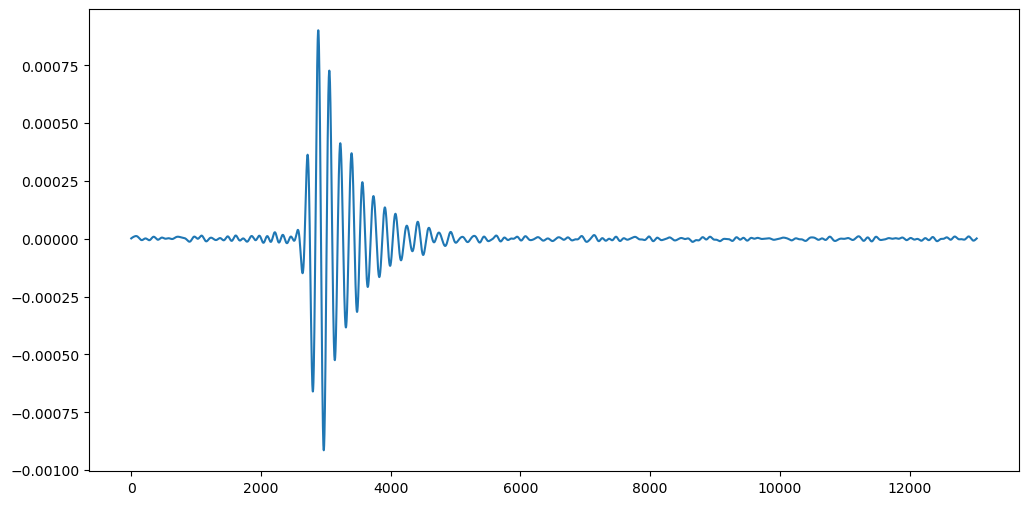

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(channel.get_trace())
plt.show()

In [9]:
reader0 = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})
evt0 = reader0.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=0 * units.K)

WARNING - 2026-07-03 13:32:37,285 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,286 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,286 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,286 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,287 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,287 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 13:32:37,288 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 13:32:38,571 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,571 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,572 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,572 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,573 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,573 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 13:32:38,574 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 13:32:39,775 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,775 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,776 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,776 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,777 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,777 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 13:32:39,777 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 13:32:43,042 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,043 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,043 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,044 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,044 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,044 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,045 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 13:32:43,775 - NuRadioReco.detector - Cable delay not set for channel 7911095 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,776 - NuRadioReco.detector - Cable delay not set for channel 7000000 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,782 - NuRadioReco.efieldToVoltageConverter - Frequencies have changed (array length). Clearing antenna response cache. If you similate neutrinos/in-ice radio emission, this is not surprising. Please disable caching By passing `caching==False` to the begin method. If you simulate air showers and this happens often, something might be wrong...
WARNING - 2026-07-03 13:32:43,794 - NuRadioReco.detector - Cable delay not set for channel 7000001 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,812 - NuRadioReco.detector - Cable delay not set for channel 7000002 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 13:32:43,824 - NuRadioReco.detector -

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


In [29]:
st0 = evt0.get_station(6)
chan0 = st0.get_channel(st0.get_channel_ids()[45])

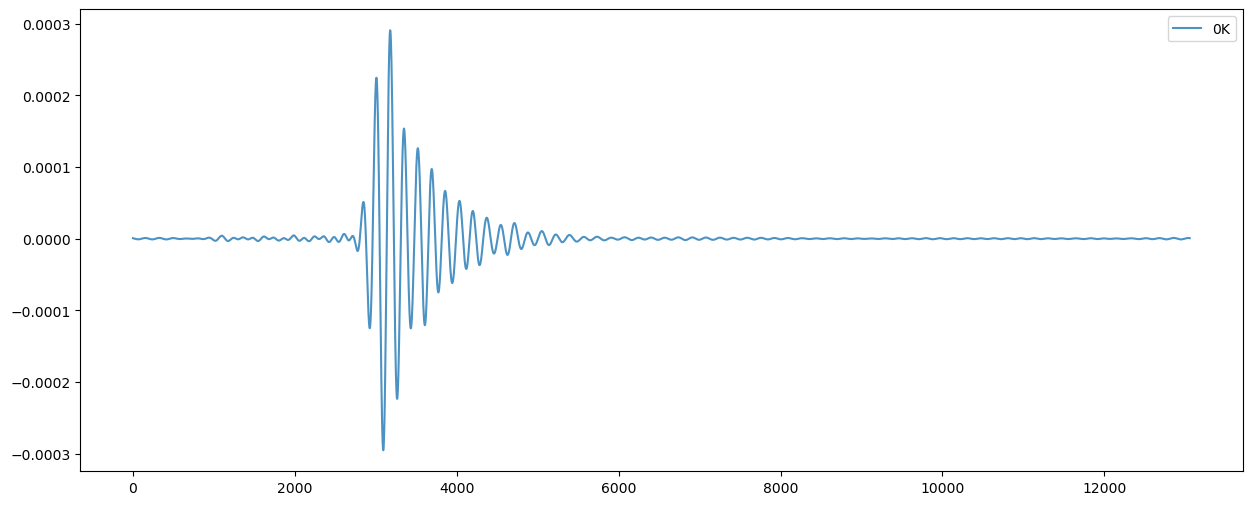

In [30]:
plt.figure(figsize=(15, 6))
# plt.plot(channel.get_trace(), label="300K")
plt.plot(chan0.get_trace(), label="0K", alpha=0.8)
plt.legend()
plt.show()

In [31]:
len(st0.get_channel_ids())

192